# Using C&T after the integration, run first the imputation for acet and me to increase the resolution and then run inference of bins corresponding to genes resulting in a matrix with acet and meth counts for genes

In [2]:
import sys
import numpy as np
import pandas as pd
import anndata as ad

sys.path.insert(0, '../toolkit-project/')

import src as scit
import anndata as ad
import igraph as ig

In [3]:
scit.set_defaults(figsize = (7,7))

In [5]:
# ctad = ad.read_h5ad("../h5ad/ctag_ilb-250218.h5ad")
ctad = ad.read_h5ad("../h5ad/cuttag_ilb_inferred-250218.h5ad")

In [6]:
scit.gr.knn(ctad, 'X_glue', n_neighbors=4)
g = scit.gr.neighbor_graph(ctad)
scit.gr.knn_impute(ctad, g, ['acet', 'meth'], 0.7)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Info: Imputing layers ['acet', 'meth'] with number of neighbors per cell of 6 and strength of 0.7.


In [7]:
ctad.obs

,batch,meth_total_counts,meth_log_total_counts,acet_total_counts,acet_log_total_counts,exclude,timep,leiden_ms,label,leiden_glue,acet_binary_total_counts,acet_binary_log_total_counts,meth_binary_total_counts,meth_binary_log_total_counts,imputed_acet_total_counts,imputed_acet_log_total_counts,imputed_meth_total_counts,imputed_meth_log_total_counts
AAACGAAAGAAGACTT-e1,batch1,144,4.976734,422,6.047372,False,8_10h,0,Foregut,6,396,5.983936,134,4.905275,1700.000000,7.438972,1700.000000,7.438972
AAACGAAAGCGTCAAG-e1,batch1,58,4.077537,256,5.549076,False,8_10h,1,Epidermis,4,233,5.455321,52,3.970292,1700.000000,7.438972,1700.000000,7.438972
AAACGAACAACAACTC-e1,batch1,293,5.683580,1651,7.409742,False,8_10h,1,Muscle,0,224,5.416100,174,5.164786,1700.000000,7.438972,1700.000000,7.438972
AAACGAACACACATTG-e1,batch1,110,4.709530,429,6.063785,False,8_10h,0,Pharnyx,10,386,5.958425,104,4.653960,1700.000000,7.438972,1699.999878,7.438972
AAACGAACACCACCAG-e1,batch1,324,5.783825,1171,7.066467,False,8_10h,1,Brain,10,620,6.431331,210,5.351858,1700.000122,7.438972,1700.000000,7.438972
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTGTGTGAATGTA-l2,batch2,242,5.493061,394,5.978886,False,14_16h,0,Epidermis,9,380,5.942799,174,5.164786,1700.000000,7.438972,1699.999878,7.438972
TTTGTGTGTGCTTGAT-l2,batch2,235,5.463832,476,6.167516,False,14_16h,3,Midgut,8,451,6.113682,160,5.081404,1700.000000,7.438972,1700.000122,7.438972
TTTGTGTGTTTGCGAT-l2,batch2,180,5.198497,619,6.429719,False,14_16h,4,Midgut,1,581,6.366470,150,5.017280,1700.000000,7.438972,1699.999878,7.438972
TTTGTGTTCCAACCTC-l2,batch2,84,4.442651,193,5.267858,False,14_16h,1,Pharnyx,10,185,5.225747,78,4.369448,1699.999878,7.438972,1700.000000,7.438972


In [11]:
#scit.em.umap(ctad, "X_glue")

In [8]:
ctad.var

,acet_total_counts,acet_log_total_counts,meth_total_counts,meth_log_total_counts,acet_binary_total_counts,acet_binary_log_total_counts,meth_binary_total_counts,meth_binary_log_total_counts,imputed_acet_total_counts,imputed_acet_log_total_counts,imputed_meth_total_counts,imputed_meth_log_total_counts,chr,start,end
chr2L:10000-15000,447,6.104793,208,5.342334,344,5.843544,170,5.141664,1647.274780,7.407485,1728.595581,7.455643,chr2L,10000,15000
chr2L:100000-105000,580,6.364751,97,4.584967,383,5.950643,81,4.406719,1842.360718,7.519346,693.039734,6.542529,chr2L,100000,105000
chr2L:10000000-10005000,896,6.799056,181,5.204007,505,6.226537,141,4.955827,2847.027344,7.954382,1396.496094,7.242437,chr2L,10000000,10005000
chr2L:10005000-10010000,712,6.569481,126,4.844187,465,6.144186,99,4.605170,2465.640137,7.810612,863.046082,6.761626,chr2L,10005000,10010000
chr2L:10010000-10015000,751,6.622736,136,4.919981,475,6.165418,109,4.700480,2607.000732,7.866339,951.184387,6.858759,chr2L,10010000,10015000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
chrX:9985000-9990000,204,5.323010,61,4.127134,178,5.187386,54,4.007333,875.197876,6.775592,537.218262,6.288264,chrX,9985000,9990000
chrX:9990000-9995000,234,5.459586,61,4.127134,208,5.342334,52,3.970292,993.882690,6.902625,464.087158,6.142225,chrX,9990000,9995000
chrX:9995000-10000000,351,5.863631,93,4.543295,273,5.613128,82,4.418841,1232.009766,7.117213,794.049805,6.678405,chrX,9995000,10000000
chrY:1420000-1425000,20,3.044522,23,3.178054,19,2.995732,22,3.135494,48.602402,3.904039,141.935181,4.962391,chrY,1420000,1425000


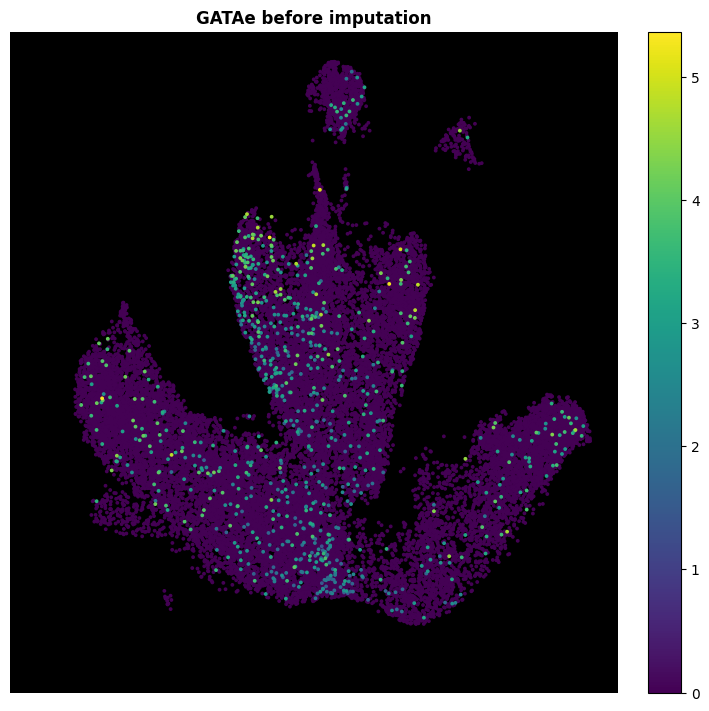

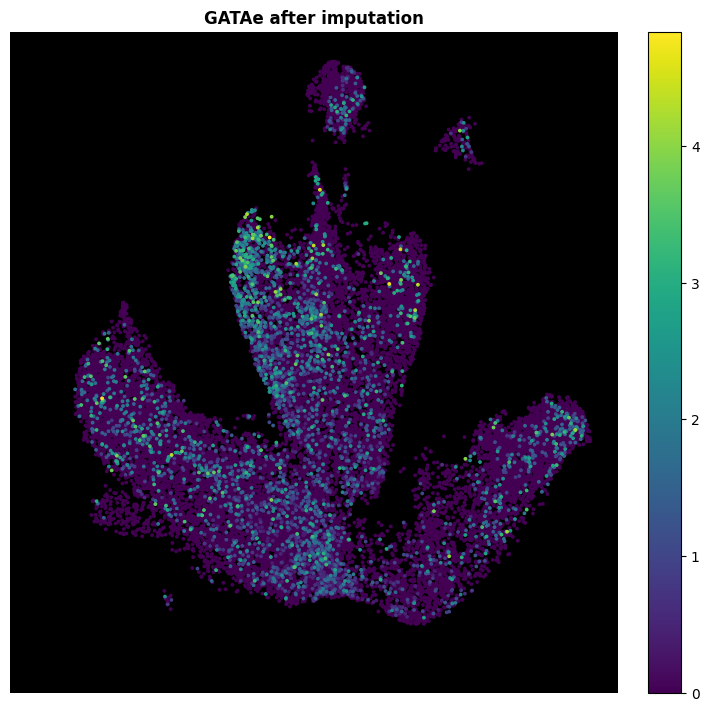

In [9]:
pre_imp_acet = scit.tl.make_layer_config('acet', log_transform=True,
                                         normalize_with_obs_counts=True, feature_names=ctad.var_names)
imputed_acet = scit.tl.make_layer_config('imputed_acet', log_transform=True,
                                         normalize_with_obs_counts=True, feature_names=ctad.var_names)

# Change var index to find a suitable var as an example
# var_index = 'chr3R:7085000-7090000'
var_index = 'chr3R:16005000-16010000' #GATAe
# var_index = 'chrX:520000-525000' #elav
# var_index = 'chrX:535000-540000' #elav2

scit.tl.layer_pick_features(ctad, pre_imp_acet, var_index)
scit.tl.copy_to_obs(ctad, pre_imp_acet)
scit.pl.embedding2d(ctad, 'X_umap', 'copied_data', black_background=True, title = 'GATAe before imputation')

scit.tl.layer_pick_features(ctad, imputed_acet, var_index)
scit.tl.copy_to_obs(ctad, imputed_acet)
scit.pl.embedding2d(ctad, 'X_umap', 'copied_data', black_background=True, title = 'GATAe after imputation')

In [10]:
import pickle
with open("../go_reg/reg.pickle", "rb") as f:
    reg = pickle.load(f)
with open("../go_reg/gene-names.pickle", "rb") as f:
    names = pickle.load(f)

In [11]:
reg.df[reg.df['name'] == "elav"]

,chr,start,end,chr2,start2,end2,score,pval,qval,name,binname
25455,chrX,522726,523726,chrX,535000,540000,0.673634,0.023100,0.038623,elav,chrX:535000-540000
30067,chrX,522726,523726,chrX,540000,545000,0.665553,0.025052,0.040927,elav,chrX:540000-545000
47748,chrX,522726,523726,chrX,530000,535000,0.760115,0.008630,0.019518,elav,chrX:530000-535000
52127,chrX,522726,523726,chrX,515000,520000,0.645642,0.030509,0.047315,elav,chrX:515000-520000
54784,chrX,522726,523726,chrX,520000,525000,0.717986,0.014435,0.027666,elav,chrX:520000-525000


Add promoters to the regulatory links file and modify var to include bins coordinates

In [13]:
from src.tools._regulation import regulatory_ensure_promoter_included

In [12]:
rna = ad.read_h5ad("../h5ad/glue_emb-2-rna_SHORT.h5ad")

In [14]:
scit.tl.add_metadata(ctad)

In [15]:
ctad.var['chr'] = pd.Categorical(ctad.var['chr'])

In [16]:
regulatory_ensure_promoter_included(reg, ctad, rna)

In [17]:
ctad

AnnData object with n_obs × n_vars = 27645 × 24130
    obs: 'batch', 'meth_total_counts', 'meth_log_total_counts', 'acet_total_counts', 'acet_log_total_counts', 'exclude', 'timep', 'leiden_ms', 'label', 'leiden_glue', 'acet_binary_total_counts', 'acet_binary_log_total_counts', 'meth_binary_total_counts', 'meth_binary_log_total_counts', 'imputed_acet_total_counts', 'imputed_acet_log_total_counts', 'imputed_meth_total_counts', 'imputed_meth_log_total_counts', 'copied_data'
    var: 'acet_total_counts', 'acet_log_total_counts', 'meth_total_counts', 'meth_log_total_counts', 'acet_binary_total_counts', 'acet_binary_log_total_counts', 'meth_binary_total_counts', 'meth_binary_log_total_counts', 'imputed_acet_total_counts', 'imputed_acet_log_total_counts', 'imputed_meth_total_counts', 'imputed_meth_log_total_counts', 'chr', 'start', 'end'
    uns: 'colors_dict', 'gene_names_acet_binary', 'gene_names_acet_imp', 'gene_names_meth_binary', 'gene_names_meth_imp'
    obsm: 'X_acetylation', 'X_glue',

In [18]:
R = scit.tl.get_regulatory_matrix(reg, names, ctad.var_names)

In [18]:
lc_meth = scit.tl.make_layer_config(
    'meth_binary'
)
lc_acet = scit.tl.make_layer_config(
    'acet_binary'
)

scit.tl.infer_layer(ctad, R, lc_acet, names, 'acet_binary')
scit.tl.infer_layer(ctad, R, lc_meth, names, 'meth_binary')



In [19]:
lc_meth = scit.tl.make_layer_config(
    'imputed_meth'
)
lc_acet = scit.tl.make_layer_config(
    'imputed_acet'
)

scit.tl.infer_layer(ctad, R, lc_acet, names, 'acet_imp')
scit.tl.infer_layer(ctad, R, lc_meth, names, 'meth_imp')



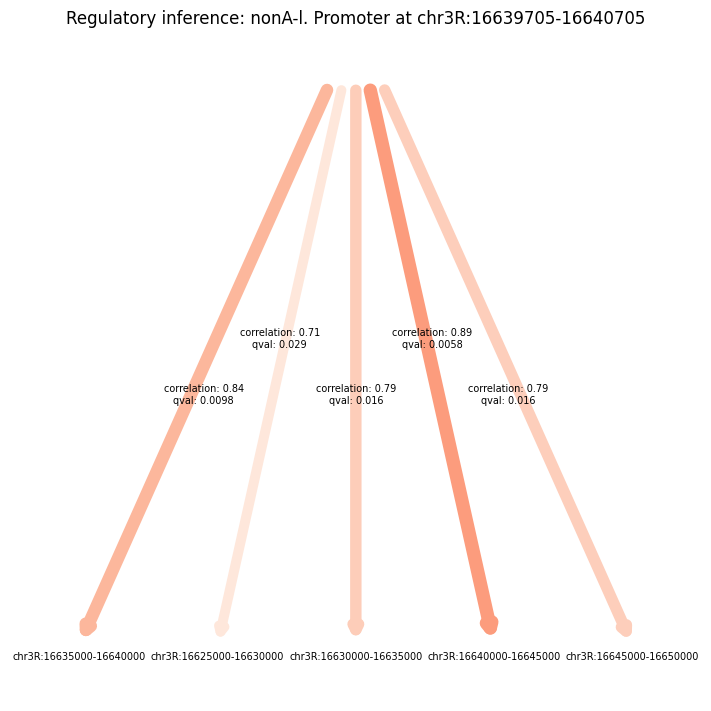

In [21]:
# Visualize Oli regulation

scit.pl.regulatory_links(reg, 'nonA-l')

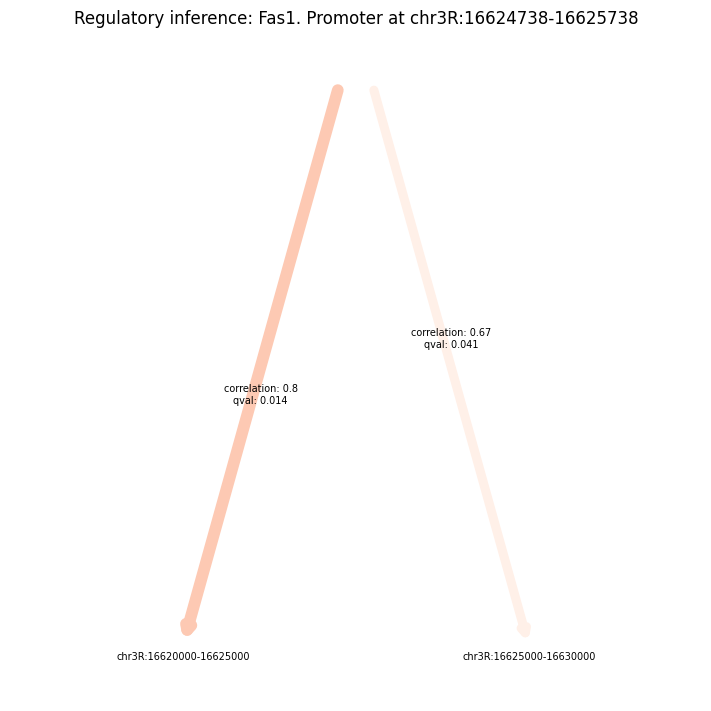

In [22]:
# Visualize Oli regulation

scit.pl.regulatory_links(reg, 'Fas1')

/faststorage/project/PAN_illumina/people/artem/singlecell/jnb/toolkit-project/src/plotting/_inference.py:52: RuntimeWarning: divide by zero encountered in log
  color = _cmap(qval_norm(np.log(el['qval'])))


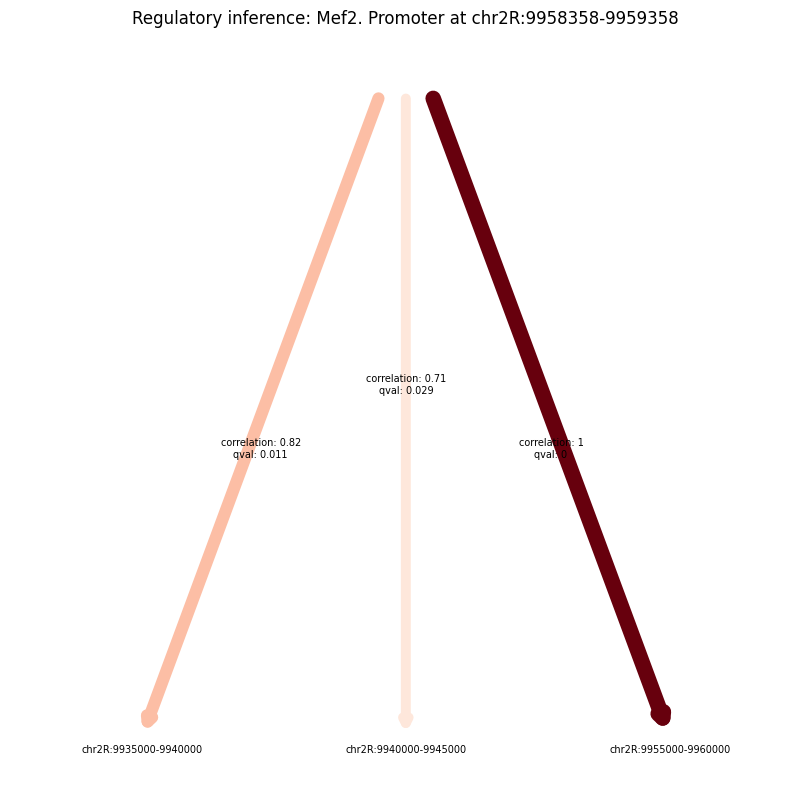

In [23]:
# Visualize Oli regulation

scit.pl.regulatory_links(reg, 'Mef2')

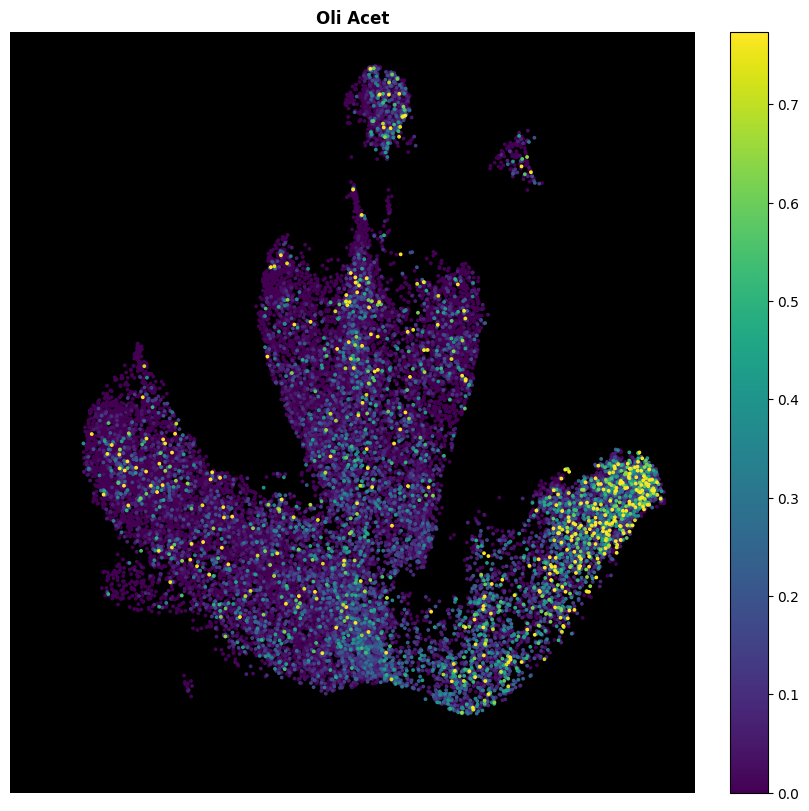

In [29]:
# The inferred data is in .obsm (since feature number is different)

acet = scit.tl.make_layer_config('acet_imp', in_obsm=True, feature_names=names, feature_active_threshold=0)

# Visualize Oli gene acetylation

scit.tl.layer_pick_features(ctad, acet, 'Oli')
scit.tl.copy_to_obs(ctad, acet)
scit.pl.embedding2d(ctad, 'X_umap', 'copied_data', black_background=True, title = "Oli Acet",
                    vminmax= (0, np.quantile(ctad.obs['copied_data'], q = 0.99)))


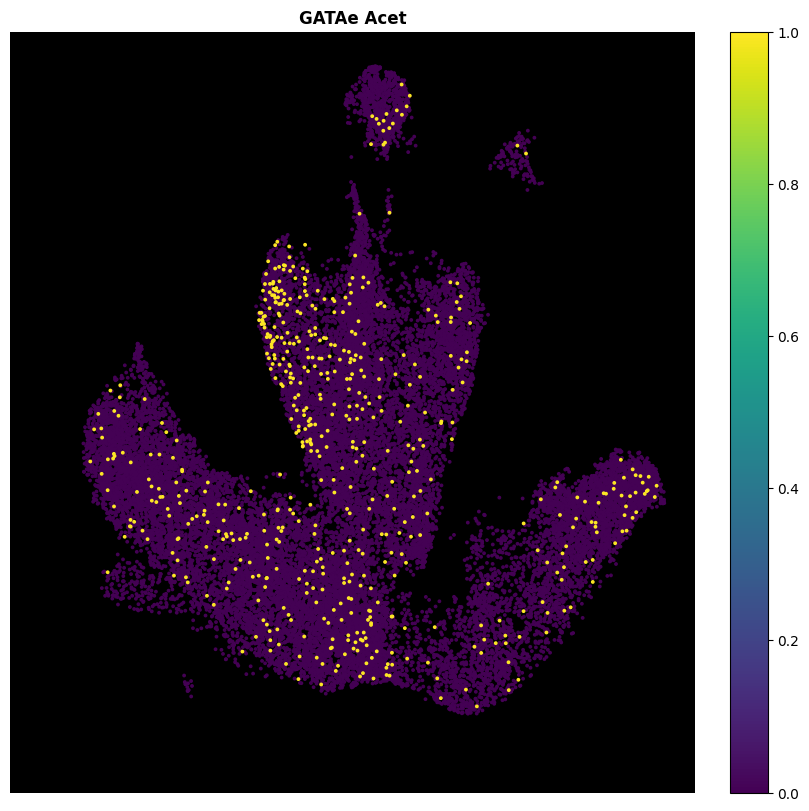

In [31]:
# The inferred data is in .obsm (since feature number is different)

acet = scit.tl.make_layer_config('acet_binary', in_obsm=True, feature_names=names, feature_active_threshold=0)

# Visualize Oli gene acetylation

scit.tl.layer_pick_features(ctad, acet, 'GATAe')
scit.tl.copy_to_obs(ctad, acet)
scit.pl.embedding2d(ctad, 'X_umap', 'copied_data', black_background=True, title = "GATAe Acet")


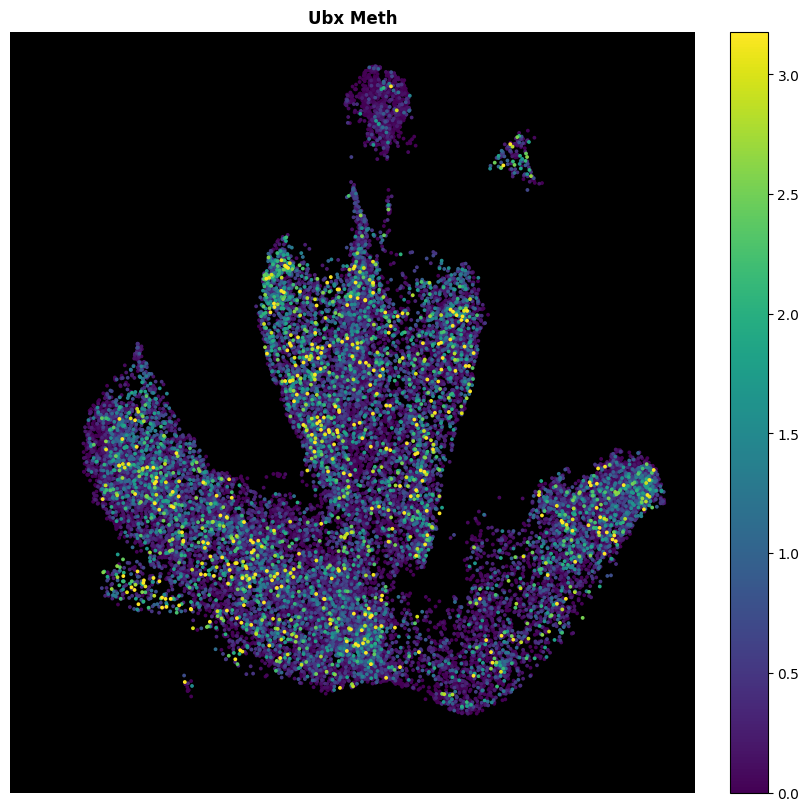

In [33]:
meth = scit.tl.make_layer_config('meth_imp', in_obsm=True, feature_names=names, feature_active_threshold=0)

# Visualize gene methylation

scit.tl.layer_pick_features(ctad, meth, 'Ubx')
scit.tl.copy_to_obs(ctad, meth)
scit.pl.embedding2d(ctad, 'X_umap', 'copied_data', black_background=True, title = "Ubx Meth",
                   vminmax= (0, np.quantile(ctad.obs['copied_data'], q = 0.99)))


In [34]:
del ctad.obs['copied_data']

In [35]:
ctad.write_h5ad("../h5ad/cuttag_ilb_inferred-250218.h5ad")